In [26]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
from codecarbon import EmissionsTracker # Pour le critère environnemental

In [27]:
# --- 1. CHARGEMENT ET NETTOYAGE ---
def load_and_prepare_data(file_path):
    df = pd.read_csv(file_path)
    # Conversion de la date en format datetime UTC [cite: 12]
    df['date'] = pd.to_datetime(df['date'])
    # Tri par alerte et par temps pour le calcul des deltas [cite: 23]
    df = df.sort_values(['airport_alert_id', 'date'])
    return df


In [28]:
def build_robust_features(df):
    """
    Construit les caractéristiques (features) pour XGBoost capables de gérer
    des alertes de 1 à 2500 éclairs.
    """
    print("Construction des features dynamiques...")
    # On s'assure que tout est bien trié chronologiquement par alerte
    df = df.dropna(subset=['airport_alert_id']).copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['airport_alert_id', 'date'])
    
    # --- 1. CARACTÉRISTIQUES GLOBALES (Depuis le début de l'alerte) ---
    
    # Numéro de l'éclair dans l'alerte (1, 2, 3...)
    df['eclair_id_in_alert'] = df.groupby('airport_alert_id').cumcount() + 1
    
    # Temps écoulé depuis le TOUT PREMIER éclair de l'alerte (en minutes)
    df['time_since_start'] = df.groupby('airport_alert_id')['date'].transform(
        lambda x: (x - x.min()).dt.total_seconds() / 60.0
    )
    
    # Différence de distance par rapport au PREMIER éclair
    # Si > 0, l'orage s'est éloigné de son point d'origine
    first_dist = df.groupby('airport_alert_id')['dist'].transform('first')
    df['dist_diff_from_start'] = df['dist'] - first_dist

    # --- 2. CARACTÉRISTIQUES LOCALES (Fenêtres glissantes) ---
    
    # Temps depuis le DERNIER éclair (dt) en minutes
    df['dt_previous'] = df.groupby('airport_alert_id')['date'].diff().dt.total_seconds() / 60.0
    df['dt_previous'] = df['dt_previous'].fillna(0) # 0 pour le premier éclair
    
    # Vitesse radiale instantanée (km/min)
    df['v_radial_inst'] = df.groupby('airport_alert_id')['dist'].diff() / df['dt_previous'].replace(0, np.nan)
    df['v_radial_inst'] = df['v_radial_inst'].fillna(0)
    
    # Ratio d'intra-nuages (icloud) sur les 5 DERNIERS éclairs (ou moins si on est au début)
    df['ratio_ic_5'] = df.groupby('airport_alert_id')['icloud'].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean()
    )
    
    # --- 3. PRÉPARATION DE LA MATRICE XGBOOST ---
    
    # La cible (Target)
    df['target'] = df['is_last_lightning_cloud_ground'].fillna(False).astype(int)
    
    # Sélection des colonnes finales
    features_cols = [
        'dist', 'amplitude', 'icloud', 'azimuth',        # Variables physiques pures
        'eclair_id_in_alert', 'time_since_start',        # Contexte global de l'alerte
        'dist_diff_from_start',                          # Dynamique globale
        'dt_previous', 'v_radial_inst', 'ratio_ic_5'     # Dynamique locale (rythme)
    ]
    
    X = df[features_cols]
    y = df['target']
    
    print(f"Matrice prête : {X.shape[0]} lignes, {X.shape[1]} features.")
    return X, y, df

# Utilisation
# X_train, y_train, df_train_complet = build_robust_features(votre_dataframe_train)

In [29]:
# --- 3. PIPELINE PRINCIPAL ---
df = pd.read_csv('./segment_alerts_all_airports_train.csv')

# --- On suppose que tu viens d'exécuter la fonction précédente ---
X_complet, y_complet, df_complet = build_robust_features(df)

# ==========================================
# 4. SÉPARATION TRAIN / TEST (Sans fuite de données)
# ==========================================
print("\nSéparation des données (80% Train / 20% Test)...")

# On liste les alertes dans l'ordre chronologique
alert_ids = df_complet['airport_alert_id'].unique()
split_idx = int(len(alert_ids) * 0.8) 

train_alerts = alert_ids[:split_idx]
test_alerts = alert_ids[split_idx:]

# Création des ensembles en gardant les alertes intactes
df_train = df_complet[df_complet['airport_alert_id'].isin(train_alerts)]
df_test = df_complet[df_complet['airport_alert_id'].isin(test_alerts)]

# Sélection des colonnes features
features_cols = [
    'dist', 'amplitude', 'icloud', 'azimuth',
    'eclair_id_in_alert', 'time_since_start', 'dist_diff_from_start',
    'dt_previous', 'v_radial_inst', 'ratio_ic_5'
]

X_train, y_train = df_train[features_cols], df_train['target']
X_test, y_test = df_test[features_cols], df_test['target']



Construction des features dynamiques...
Matrice prête : 56599 lignes, 10 features.

Séparation des données (80% Train / 20% Test)...


/var/folders/cp/jbw310tj0zxgd9b5vq7rlyr00000gn/T/ipykernel_3570/362798442.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['target'] = df['is_last_lightning_cloud_ground'].fillna(False).astype(int)


In [30]:
# ==========================================
# 5. ENTRAÎNEMENT XGBOOST
# ==========================================
# Calcul du ratio exact pour le scale_pos_weight
ratio = len(y_train[y_train == 0]) / max(len(y_train[y_train == 1]), 1)
print(f"Ratio calculé pour XGBoost (scale_pos_weight) : {ratio:.1f}")

tracker = EmissionsTracker()
tracker.start()

model = xgb.XGBClassifier(
    n_estimators=150,         # Un peu plus d'arbres pour capter les nuances
    max_depth=6,
    learning_rate=0.05,       # Apprentissage plus doux
    scale_pos_weight=ratio,   # Gère le déséquilibre massif
    objective='binary:logistic',
    tree_method='hist'        # Optimisation CPU et Carbone
)

model.fit(X_train, y_train)
tracker.stop()


[codecarbon WARNING @ 21:00:50] Multiple instances of codecarbon are allowed to run at the same time.


Ratio calculé pour XGBoost (scale_pos_weight) : 20.0


[codecarbon WARNING @ 21:00:51] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.
[codecarbon INFO @ 21:00:51] [setup] RAM Tracking...
[codecarbon INFO @ 21:00:51] [setup] CPU Tracking...
[codecarbon WARNING @ 21:00:52] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon INFO @ 21:00:52] CPU Model on constant consumption mode: Apple M1
[codecarbon WARNING @ 21:00:52] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 21:00:52] [setup] GPU Tracking...
[codecarbon INFO @ 21:00:52] No GPU found.
[codecarbon INFO @ 21:00:52] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 21:00:52] >>> Tracker

5.914142483236338e-07

In [31]:
# ==========================================
# 6. ÉVALUATION MÉTIER (Le vrai test)
# ==========================================
print("\nCalcul des prédictions...")
probs = model.predict_proba(X_test)[:, 1]
df_test['proba_fin'] = probs

# On fixe un seuil d'exigence (ex: 85% de certitude)
seuil_decision = 0.85
preds = (probs > seuil_decision).astype(int)

print("\n--- Rapport de Classification ML ---")
print(classification_report(y_test, preds))
print(f"AUC Score: {roc_auc_score(y_test, probs):.4f}")



# --- FONCTION DE CALCUL DU LEAD TIME ---
def evaluate_lead_time(df_test, seuil=0.85):
    print(f"\n--- Évaluation Métier (Seuil IA: {seuil*100}%) ---")
    gains_minutes = []
    violations = 0
    
    for alert_id, group in df_test.groupby('airport_alert_id'):
        # On cherche la vraie fin de l'alerte
        vraies_fins = group[group['target'] == 1]
        if vraies_fins.empty:
            continue # Alerte probablement coupée ou invalide, on passe
            
        t_last_real = vraies_fins['date'].iloc[-1]
        t_reprise_reglementaire = t_last_real + pd.Timedelta(minutes=30)
        
        # IA : L'alerte est levée au premier éclair où P > seuil
        predictions_positives = group[group['proba_fin'] >= seuil]
        
        if not predictions_positives.empty:
            t_reprise_ia = predictions_positives['date'].iloc[0]
            
            # Vérification SÉCURITÉ : y a-t-il eu un éclair au sol APRES cette décision ?
            # On cherche les éclairs postérieurs à la décision IA
            eclairs_futurs = group[(group['date'] > t_reprise_ia)]
            
            if not eclairs_futurs.empty:
                violations += 1 # L'IA a levé l'alerte trop tôt !
            else:
                # Tout va bien, on calcule le gain
                gain = (t_reprise_reglementaire - t_reprise_ia).total_seconds() / 60.0
                gains_minutes.append(gain)
                
    gain_moyen = np.mean(gains_minutes) if gains_minutes else 0
    total_alertes = len(df_test['airport_alert_id'].unique())
    
    print(f"--> Gain de temps moyen validé : {gain_moyen:.1f} minutes par alerte.")
    print(f"--> Violations de sécurité     : {violations} / {total_alertes} alertes testées")
    
    return gain_moyen, violations




Calcul des prédictions...

--- Rapport de Classification ML ---
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      4571
           1       0.28      0.41      0.33       154

    accuracy                           0.95      4725
   macro avg       0.63      0.69      0.65      4725
weighted avg       0.96      0.95      0.95      4725

AUC Score: 0.9119


/var/folders/cp/jbw310tj0zxgd9b5vq7rlyr00000gn/T/ipykernel_3570/1955961462.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['proba_fin'] = probs


In [32]:
# Exécution de l'évaluation
evaluate_lead_time(df_test, seuil=seuil_decision)


--- Évaluation Métier (Seuil IA: 85.0%) ---
--> Gain de temps moyen validé : 30.0 minutes par alerte.
--> Violations de sécurité     : 107 / 154 alertes testées


(np.float64(30.0), 107)

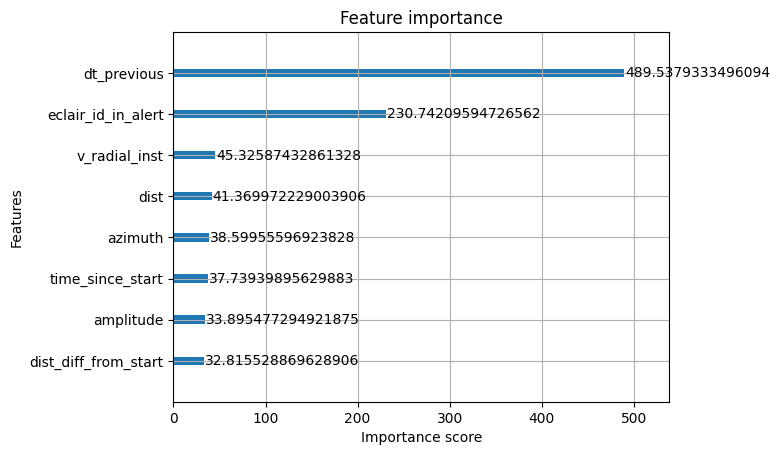

In [33]:
import matplotlib.pyplot as plt
xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.show()

In [34]:
print("\n=== RECHERCHE DU SEUIL OPTIMAL DE SÉCURITÉ ===")
# On teste des seuils de plus en plus stricts
seuils_a_tester = [0.85, 0.90, 0.95, 0.98, 0.99, 0.995, 0.999]

for seuil in seuils_a_tester:
    gain, violations = evaluate_lead_time(df_test, seuil=seuil)
    
    # Si on atteint le zéro violation, on a trouvé notre modèle de production !
    if violations == 0:
        print(f"\n✅ BINGO ! Seuil de production trouvé à {seuil*100}% de certitude.")
        print(f"Gain garanti sans AUCUN risque : {gain:.1f} minutes par alerte.")
        break


=== RECHERCHE DU SEUIL OPTIMAL DE SÉCURITÉ ===

--- Évaluation Métier (Seuil IA: 85.0%) ---
--> Gain de temps moyen validé : 30.0 minutes par alerte.
--> Violations de sécurité     : 107 / 154 alertes testées

--- Évaluation Métier (Seuil IA: 90.0%) ---
--> Gain de temps moyen validé : 30.0 minutes par alerte.
--> Violations de sécurité     : 86 / 154 alertes testées

--- Évaluation Métier (Seuil IA: 95.0%) ---
--> Gain de temps moyen validé : 30.0 minutes par alerte.
--> Violations de sécurité     : 1 / 154 alertes testées

--- Évaluation Métier (Seuil IA: 98.0%) ---
--> Gain de temps moyen validé : 0.0 minutes par alerte.
--> Violations de sécurité     : 0 / 154 alertes testées

✅ BINGO ! Seuil de production trouvé à 98.0% de certitude.
Gain garanti sans AUCUN risque : 0.0 minutes par alerte.


In [35]:
def evaluate_lead_time_hybride(df_test, seuil_ia=0.95):
    gains_minutes = []
    violations = 0
    
    for alert_id, group in df_test.groupby('airport_alert_id'):
        vraies_fins = group[group['target'] == 1]
        if vraies_fins.empty: continue
            
        t_last_real = vraies_fins['date'].iloc[-1]
        t_reprise_reglementaire = t_last_real + pd.Timedelta(minutes=30)
        
        # RÈGLE HYBRIDE : IA > 95% ET (dt_previous > 5 min)
        # On force l'IA à attendre au moins 5 min de "silence" avant de valider sa certitude
        predictions_valides = group[
            (group['proba_fin'] >= seuil_ia) & 
            (group['dt_previous'] >= 5.0) 
        ]
        
        if not predictions_valides.empty:
            t_reprise_ia = predictions_valides['date'].iloc[0]
            eclairs_futurs = group[(group['date'] > t_reprise_ia)]
            
            if not eclairs_futurs.empty:
                violations += 1
            else:
                gain = (t_reprise_reglementaire - t_reprise_ia).total_seconds() / 60.0
                gains_minutes.append(gain)
                
    gain_moyen = np.mean(gains_minutes) if gains_minutes else 0
    return gain_moyen, violations

# Test direct :
for seuil in [0.80, 0.85, 0.90, 0.95]:
    gain, vio = evaluate_lead_time_hybride(df_test, seuil_ia=seuil)
    print(f"--- Modèle Hybride (IA {seuil*100:.1f}% + Garde-Fou 5min) ---")
    print(f"Gain moyen : {gain:.1f} minutes")
    print(f"Violations : {vio}")

--- Modèle Hybride (IA 80.0% + Garde-Fou 5min) ---
Gain moyen : 30.0 minutes
Violations : 55
--- Modèle Hybride (IA 85.0% + Garde-Fou 5min) ---
Gain moyen : 30.0 minutes
Violations : 41
--- Modèle Hybride (IA 90.0% + Garde-Fou 5min) ---
Gain moyen : 30.0 minutes
Violations : 7
--- Modèle Hybride (IA 95.0% + Garde-Fou 5min) ---
Gain moyen : 0.0 minutes
Violations : 0


In [36]:
def simulate_real_time_dashboard(df_test, model, seuil_ia=0.95):
    gains_minutes = []
    violations = 0
    
    # On itère sur chaque alerte de test
    for alert_id, group in df_test.groupby('airport_alert_id'):
        vraies_fins = group[group['target'] == 1]
        if vraies_fins.empty: continue
            
        t_last_real = vraies_fins['date'].iloc[-1]
        t_reprise_reglementaire = t_last_real + pd.Timedelta(minutes=30)
        
        alerte_levee = False
        
        # On parcourt tous les éclairs de l'alerte
        for i in range(len(group)):
            eclair_actuel = group.iloc[i]
            t_actuel = eclair_actuel['date']
            
            # 1. On vérifie si l'IA lève l'alerte PILE au moment de l'éclair
            if eclair_actuel['proba_fin'] >= seuil_ia:
                t_reprise_ia = t_actuel
                alerte_levee = True
            else:
                # 2. SIMULATION DU TEMPS QUI PASSE (Le secret est ici)
                # On attend minute par minute jusqu'au prochain éclair (ou jusqu'à 30 min max)
                t_prochain_eclair = group.iloc[i+1]['date'] if i + 1 < len(group) else t_reprise_reglementaire
                
                # On crée un "faux" éclair qui est juste le précédent qui vieillit
                vecteur_features = eclair_actuel[features_cols].copy()
                
                for minutes_attente in range(1, 31):
                    t_simule = t_actuel + pd.Timedelta(minutes=minutes_attente)
                    if t_simule >= t_prochain_eclair:
                        break # Un vrai éclair vient de tomber, on sort de l'attente
                        
                    # On met à jour le chronomètre pour l'IA
                    vecteur_features['dt_previous'] = eclair_actuel['dt_previous'] + minutes_attente
                    vecteur_features['time_since_start'] = eclair_actuel['time_since_start'] + minutes_attente
                    
                    # On recalcule la probabilité avec le temps écoulé !
                    proba_simulee = model.predict_proba(pd.DataFrame([vecteur_features]))[0, 1]
                    
                    if proba_simulee >= seuil_ia:
                        t_reprise_ia = t_simule
                        alerte_levee = True
                        break
            
            # Si l'alerte a été levée par l'IA (soit pile sur l'éclair, soit pendant l'attente)
            if alerte_levee:
                # VÉRIFICATION SÉCURITÉ : Reste-t-il des éclairs après cette heure ?
                eclairs_futurs = group[group['date'] > t_reprise_ia]
                if not eclairs_futurs.empty:
                    violations += 1
                else:
                    gain = (t_reprise_reglementaire - t_reprise_ia).total_seconds() / 60.0
                    if gain > 0:
                        gains_minutes.append(gain)
                break # On passe à l'alerte suivante

    gain_moyen = np.mean(gains_minutes) if gains_minutes else 0
    print(f"--- Dashboard Temps Réel (Seuil {seuil_ia*100}%) ---")
    print(f"Gain moyen validé : {gain_moyen:.3f} minutes")
    print(f"Violations        : {violations}")
    return gain_moyen, violations

# Exécution avec ton seuil ultra-sécurisé de 95%
for seuil in [0.80, 0.85, 0.90, 0.95, 0.98]:
    simulate_real_time_dashboard(df_test, model, seuil_ia=seuil)

--- Dashboard Temps Réel (Seuil 80.0%) ---
Gain moyen validé : 29.762 minutes
Violations        : 111
--- Dashboard Temps Réel (Seuil 85.0%) ---
Gain moyen validé : 28.093 minutes
Violations        : 108
--- Dashboard Temps Réel (Seuil 90.0%) ---
Gain moyen validé : 26.844 minutes
Violations        : 86
--- Dashboard Temps Réel (Seuil 95.0%) ---
Gain moyen validé : 30.000 minutes
Violations        : 1
--- Dashboard Temps Réel (Seuil 98.0%) ---
Gain moyen validé : 0.000 minutes
Violations        : 0
